# MOSAiC vs CARRA2 vs IFS-FESOM — combined comparison

Combines `MOSAiC_CARRA2_Comparison_refactor.ipynb` (CARRA2 along-track,
3-hourly) with `dt-climate_IFS-FESOM_plot_refactor.ipynb` (Climate-DT
story-nudging IFS-FESOM along-track, hourly). All plots use
`earthkit.plots.Figure`.

- **Time series**: one panel per variable with all four series — MOSAiC obs,
  CARRA2, IFS-FESOM hist, IFS-FESOM ctrl.
- **Density plots**: distributions compared on a *matched sample* — the
  3-hourly timestamps at which every dataset has a value — so the histograms
  describe the same times and are directly comparable.
- A statistics table (r, RMSD, mean |diff|, bias vs MOSAiC) on the same
  matched sample.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from earthkit.plots import Figure

In [2]:
BASE = Path.home() / "Git/PISCO_notebooks"
DATA_DIR = BASE / "Data"
OBS_FILE = DATA_DIR / "mosaic-examples/MOSAiC_obs_combined_1h_v2.nc"
FIG_DIR = BASE / "Figures"
FIG_DIR.mkdir(exist_ok=True)

K0 = 273.15

COLORS = {"MOSAiC": "grey", "CARRA2": "darkorange",
          "IFS_hist": "tab:blue", "IFS_ctrl": "tab:red"}
LABELS = {"MOSAiC": "MOSAiC", "CARRA2": "CARRA2",
          "IFS_hist": "IFS-FESOM hist", "IFS_ctrl": "IFS-FESOM ctrl"}

# IFS-FESOM along-track CSVs: original dt-climate layout first,
# PISCO layout (the files present in this repo) as fallback
IFS_FILES = {
    "IFS_2t_ctrl":   (["IFS-FESOM/2t_ctrl.csv", "Temp2m_IFS_Ctrl_MOSAiC.csv"], "2t", True),
    "IFS_2t_hist":   (["IFS-FESOM/2t_hist.csv", "Temp2m_IFS_Hist_MOSAiC.csv"], "2t", True),
    "IFS_10si_ctrl": (["IFS-FESOM/10si_ctrl.csv", "WindSpeed10m_IFS_Ctrl_MOSAiC.csv"], "10si", False),
    "IFS_10si_hist": (["IFS-FESOM/10si_hist.csv", "WindSpeed10m_IFS_Hist_MOSAiC.csv"], "10si", False),
}

## Load all three datasets along the drift

In [3]:
def load_hourly_frame(obs_file=OBS_FILE, ifs_files=IFS_FILES):
    """Hourly MOSAiC obs joined with the IFS-FESOM along-track series.

    Replaces the four copy-pasted merge blocks of the original: each CSV
    becomes a named series that aligns on the obs time index. 2t converts
    from Kelvin to deg C at load time.
    """
    obs = xr.open_dataset(obs_file)
    frame = pd.DataFrame({
        "obs_t2m": obs.temp_2m.to_series(),        # deg C
        "obs_10si": obs.wspd_vec_mean_10m.to_series(),
    })
    frame = frame[~frame.index.duplicated()]

    for name, (candidates, col, kelvin) in ifs_files.items():
        for rel in candidates:
            path = DATA_DIR / rel
            if path.exists():
                break
        else:
            raise FileNotFoundError(f"{name}: none of {candidates} in {DATA_DIR}")
        df = pd.read_csv(path, index_col=0)
        s = pd.Series(df[col].values, index=pd.to_datetime(df["time"]), name=name)
        s = s[~s.index.duplicated()]
        frame[name] = s - K0 if kelvin else s      # aligns on the time index
        print(f"{name}: {s.notna().sum()} values from {path.name}")
    return frame


def as_time_da(series):
    """Series with DatetimeIndex -> DataArray with a 'time' coord.
    earthkit.plots reads the date axis from the coordinate; a bare pandas
    Series would be plotted against integer positions."""
    return series.rename_axis("time").to_xarray()


hourly = load_hourly_frame()
hourly.describe().round(2)

IFS_2t_ctrl: 9301 values from Temp2m_IFS_Ctrl_MOSAiC.csv
IFS_2t_hist: 9301 values from Temp2m_IFS_Hist_MOSAiC.csv
IFS_10si_ctrl: 9301 values from WindSpeed10m_IFS_Ctrl_MOSAiC.csv
IFS_10si_hist: 9301 values from WindSpeed10m_IFS_Hist_MOSAiC.csv


,obs_t2m,obs_10si,IFS_2t_ctrl,IFS_2t_hist,IFS_10si_ctrl,IFS_10si_hist
count,5798.00,5835.00,9301.00,9301.00,9301.00,9301.00
mean,-19.00,5.85,-16.03,-14.66,5.76,5.79
std,11.60,2.90,13.54,13.01,2.75,2.75
min,-42.19,0.27,-37.98,-36.96,0.53,0.35
25%,-27.91,3.65,-29.30,-27.06,3.80,3.83
50%,-21.99,5.31,-15.65,-13.70,5.32,5.39
75%,-10.06,7.59,-0.65,-0.18,7.32,7.35
max,2.09,16.97,12.51,12.49,19.19,19.45


In [4]:
def load_carra2(fname, name="CARRA2"):
    """CARRA2 along-track CSV (3-hourly) -> named series."""
    df = pd.read_csv(DATA_DIR / fname, parse_dates=["Datetime"],
                     index_col="Datetime")
    return df["CARRA2"].rename(name)


# one frame per variable: hourly index, CARRA2 sparse (3-hourly)
frames = {
    "t2m": pd.DataFrame({
        "MOSAiC": hourly["obs_t2m"],
        "CARRA2": load_carra2("Temp2m_CARRA2_MOSAiC.csv"),
        "IFS_hist": hourly["IFS_2t_hist"],
        "IFS_ctrl": hourly["IFS_2t_ctrl"],
    }),
    "wspd": pd.DataFrame({
        "MOSAiC": hourly["obs_10si"],
        "CARRA2": load_carra2("WindSpeed10m_CARRA2_MOSAiC.csv"),
        "IFS_hist": hourly["IFS_10si_hist"],
        "IFS_ctrl": hourly["IFS_10si_ctrl"],
    }),
}

# matched sample: 3-hourly timestamps where every dataset has a value
matched = {key: df.dropna() for key, df in frames.items()}
for key, df in matched.items():
    print(f"{key}: {len(df)} matched 3-hourly samples, "
          f"{df.index[0]} .. {df.index[-1]}")

t2m: 1783 matched 3-hourly samples, 2019-10-24 06:00:00 .. 2020-08-31 21:00:00
wspd: 1795 matched 3-hourly samples, 2019-10-24 06:00:00 .. 2020-08-31 21:00:00


In [5]:
YLABELS = {"wspd": "10m wind speed (m s$^{-1}$)",
           "t2m": "2m temperature ($^{o}$C)"}


def stats(df, a, b):
    d = df[[a, b]].dropna()
    return {"r": round(d[a].corr(d[b]), 3),
            "rmsd": round(np.sqrt(((d[a] - d[b]) ** 2).mean()), 2),
            "abs_diff": round((d[a] - d[b]).abs().mean(), 2),
            "bias": round((d[b] - d[a]).mean(), 2),
            "n": len(d)}

## Combined time series — MOSAiC, CARRA2 and IFS-FESOM in one panel

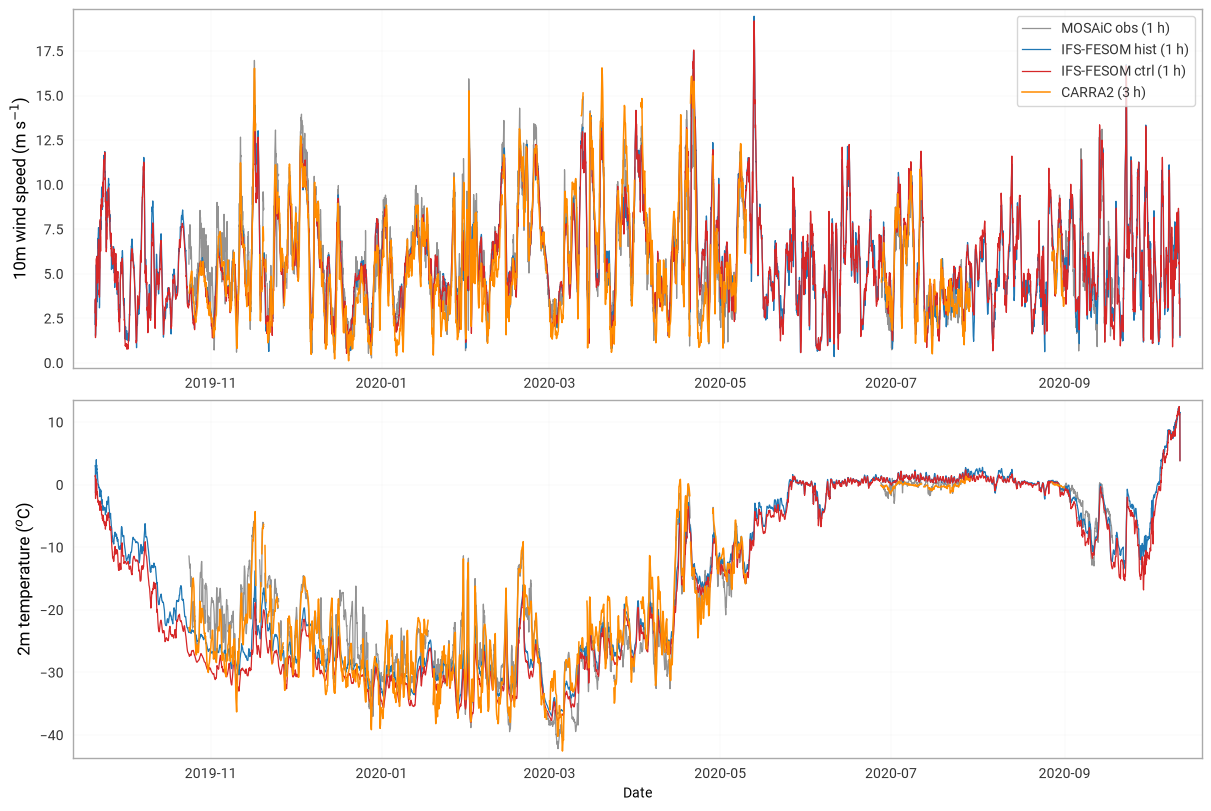

In [6]:
fig = Figure(rows=2, columns=1, size=(12, 8))

for key in ("wspd", "t2m"):
    sp = fig.add_subplot()
    sp.line(as_time_da(frames[key]["MOSAiC"]), label="MOSAiC obs (1 h)",
            color=COLORS["MOSAiC"], linewidth=0.9, alpha=0.85)
    sp.line(as_time_da(frames[key]["IFS_hist"]), label="IFS-FESOM hist (1 h)",
            color=COLORS["IFS_hist"], linewidth=0.9)
    sp.line(as_time_da(frames[key]["IFS_ctrl"]), label="IFS-FESOM ctrl (1 h)",
            color=COLORS["IFS_ctrl"], linewidth=0.9)
    # native 3 h grid: NaNs remain at real gaps so the line breaks there
    # instead of drawing a straight connector across missing months
    sp.line(as_time_da(frames[key]["CARRA2"].dropna().asfreq("3h")),
            label="CARRA2 (3 h)", color=COLORS["CARRA2"], linewidth=1.1)
    sp.ax.set_ylabel(YLABELS[key], fontsize=12)
    sp.ax.grid(linewidth=0.3)
    if key == "wspd":
        sp.legend()
    else:
        sp.xlabel("Date")

fig.save(str(FIG_DIR / "MOSAiC_CARRA2_IFS_Timeseries.png"), dpi=300,
         bbox_inches="tight")
fig.show()

## Combined density plots (matched 3-hourly sample)

Left: value distributions of all four datasets. Right: distributions of the
model − MOSAiC differences. Histograms have no earthkit-plots equivalent yet,
so they draw on the earthkit-managed matplotlib axes (`subplot.ax`).

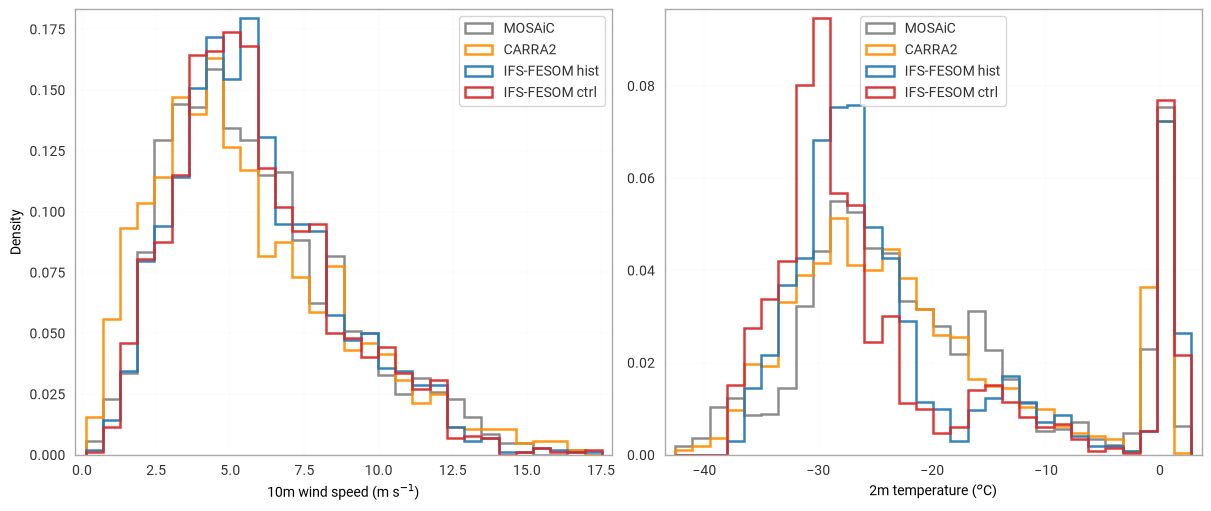

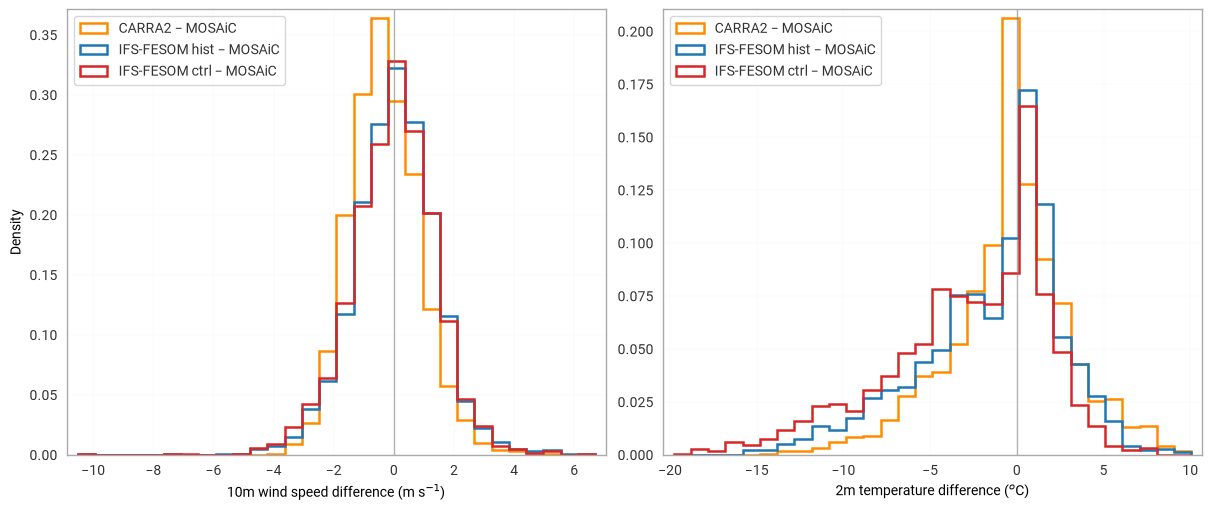

In [7]:
def density_panels(matched, save=None):
    """Per variable: value densities of all datasets on the matched sample."""
    fig = Figure(rows=1, columns=2, size=(12, 5))
    for key in ("wspd", "t2m"):
        ax = fig.add_subplot().ax
        d = matched[key]
        bins = np.histogram_bin_edges(d.to_numpy().ravel(), bins=30)
        for col in ("MOSAiC", "CARRA2", "IFS_hist", "IFS_ctrl"):
            ax.hist(d[col], bins=bins, histtype="step", density=True,
                    linewidth=1.8, edgecolor=COLORS[col],
                    alpha=0.9, label=LABELS[col])
        ax.set_xlabel(YLABELS[key])
        ax.grid(linewidth=0.2)
        ax.legend()
        if key == "wspd":
            ax.set_ylabel("Density")
    if save:
        fig.save(str(FIG_DIR / save), dpi=300, bbox_inches="tight")
    fig.show()


def difference_density_panels(matched, save=None):
    """Per variable: densities of model - MOSAiC differences."""
    fig = Figure(rows=1, columns=2, size=(12, 5))
    for key in ("wspd", "t2m"):
        ax = fig.add_subplot().ax
        d = matched[key]
        diffs = {col: d[col] - d["MOSAiC"]
                 for col in ("CARRA2", "IFS_hist", "IFS_ctrl")}
        bins = np.histogram_bin_edges(
            np.concatenate([v.to_numpy() for v in diffs.values()]), bins=30)
        for col, diff in diffs.items():
            ax.hist(diff, bins=bins, histtype="step", density=True,
                    linewidth=1.8, edgecolor=COLORS[col],
                    label=f"{LABELS[col]} − MOSAiC")
        ax.axvline(0, color="grey", linewidth=1, alpha=0.6)
        ax.set_xlabel(YLABELS[key].replace("(", "difference ("))
        ax.grid(linewidth=0.2)
        ax.legend()
        if key == "wspd":
            ax.set_ylabel("Density")
    if save:
        fig.save(str(FIG_DIR / save), dpi=300, bbox_inches="tight")
    fig.show()


density_panels(matched, save="MOSAiC_CARRA2_IFS_Density.png")
difference_density_panels(matched, save="MOSAiC_CARRA2_IFS_Difference_Density.png")

## Density scatter — each dataset versus MOSAiC

2-D density (hexbin) of every model against the observations on the matched
sample, one column per dataset, one row per variable. The grey line is 1:1;
each panel is annotated with its statistics.

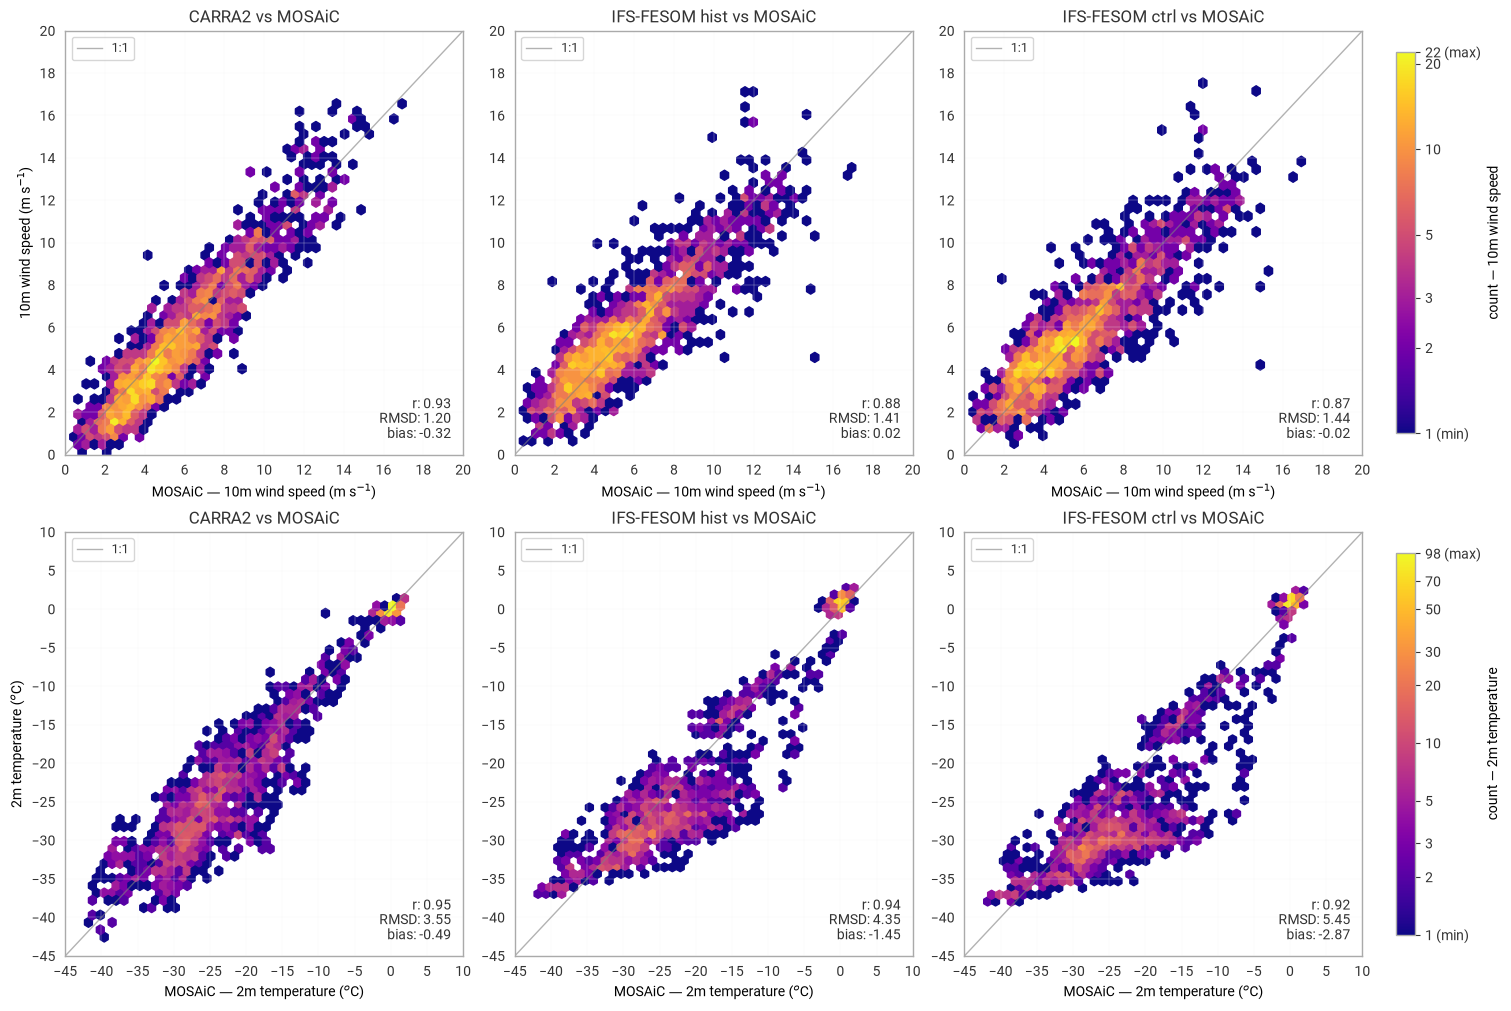

In [8]:
from matplotlib.ticker import MultipleLocator

AXLIMS = {"wspd": (0, 20), "t2m": (-45, 10)}
MODELS = ("CARRA2", "IFS_hist", "IFS_ctrl")

fig = Figure(rows=2, columns=3, size=(15, 10))
panels = {"wspd": [], "t2m": []}          # (hexbin, ax) per variable row
for key in ("wspd", "t2m"):
    for model in MODELS:
        ax = fig.add_subplot().ax
        d = matched[key]
        hb = ax.hexbin(d["MOSAiC"], d[model], gridsize=40, cmap="plasma",
                       mincnt=1)
        panels[key].append((hb, ax))
        lo, hi = AXLIMS[key]
        ax.axline((lo, lo), (hi, hi), linestyle="-", color="grey", alpha=0.6,
                  linewidth=1, label="1:1")
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_title(f"{LABELS[model]} vs MOSAiC", fontsize=12)
        ax.set_xlabel(f"MOSAiC — {YLABELS[key]}", fontsize=10)
        if model == MODELS[0]:
            ax.set_ylabel(YLABELS[key], fontsize=10)
        step = 2 if key == "wspd" else 5
        for axis in (ax.xaxis, ax.yaxis):
            axis.set_major_locator(MultipleLocator(step))
            axis.set_minor_locator(MultipleLocator(step / 2))
        ax.grid(linewidth=0.2)
        ax.legend(loc="upper left", fontsize=9)
        s = stats(d, "MOSAiC", model)
        ax.text(0.97, 0.03,
                f"r: {s['r']:.2f}\nRMSD: {s['rmsd']:.2f}\nbias: {s['bias']:.2f}",
                transform=ax.transAxes, fontsize=10, va="bottom", ha="right")

# one colour legend per variable row (wind / temperature), each on a shared
# log scale across its three panels, annotated with the row's min/max count
from matplotlib.colors import LogNorm

CBAR_TITLES = {"wspd": "count — 10m wind speed",
               "t2m": "count — 2m temperature"}
for key, items in panels.items():
    hbs = [hb for hb, _ in items]
    axs = [ax for _, ax in items]
    vmin, vmax = 1, int(max(hb.get_array().max() for hb in hbs))
    for hb in hbs:
        hb.set_norm(LogNorm(vmin=vmin, vmax=vmax))
    cbar = axs[0].figure.colorbar(hbs[0], ax=axs, label=CBAR_TITLES[key],
                                  shrink=0.9, pad=0.02)
    ticks = [t for t in (1, 2, 3, 5, 10, 20, 30, 50, 70) if t < vmax] + [vmax]
    labels = [f"{t} (min)" if t == vmin else f"{t} (max)" if t == vmax
              else str(t) for t in ticks]
    cbar.set_ticks(ticks, labels=labels)
    cbar.ax.minorticks_off()

fig.save(str(FIG_DIR / "MOSAiC_CARRA2_IFS_Density_Scatter.png"), dpi=300,
         bbox_inches="tight")
fig.show()

## Statistics vs MOSAiC (matched sample)

In [9]:
rows = []
for key in ("t2m", "wspd"):
    for col in ("CARRA2", "IFS_hist", "IFS_ctrl"):
        rows.append({"variable": key, "dataset": LABELS[col],
                     **stats(matched[key], "MOSAiC", col)})
pd.DataFrame(rows).set_index(["variable", "dataset"])

r  rmsd  abs_diff  bias     n
variable dataset                                          
t2m      CARRA2          0.951  3.55      2.59 -0.49  1783
         IFS-FESOM hist  0.935  4.35      3.19 -1.45  1783
         IFS-FESOM ctrl  0.922  5.45      3.96 -2.87  1783
wspd     CARRA2          0.932  1.20      0.96 -0.32  1795
         IFS-FESOM hist  0.878  1.41      1.06  0.02  1795
         IFS-FESOM ctrl  0.872  1.44      1.09 -0.02  1795